# Olist E-Commerce Data Cleaning

This notebook focuses on cleaning and preprocessing the Olist Brazilian E-Commerce dataset.

The main objective is to improve data quality by handling missing values, duplicate records, incorrect data types, inconsistent values, and potential outliers.

The cleaned datasets produced in this notebook will be used in subsequent exploratory data analysis, feature engineering, and machine learning stages.


## Table of Contents

1. Importing Libraries
2. Loading the Datasets
3. Initial Data Quality Check
4. Duplicate Record Analysis
5. Missing Value Analysis
6. Data Type Conversion
7. Date and Time Processing
8. Outlier Analysis
9. Data Cleaning Summary
10. Saving Cleaned Datasets
11. Conclusion

## 1. Importing Libraries

The required Python libraries are imported for data manipulation, numerical operations, visualization, and file management.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 2. Loading the Datasets

The raw Olist datasets are loaded into separate pandas DataFrames.

Keeping the datasets separate at this stage allows each table to be cleaned according to its own structure and data quality requirements.

In [2]:
RAW_DATA_PATH = "../data"

In [3]:
customers = pd.read_csv(
    os.path.join(RAW_DATA_PATH, "olist_customers_dataset.csv")
)

geolocation = pd.read_csv(
    os.path.join(RAW_DATA_PATH, "olist_geolocation_dataset.csv")
)

order_items = pd.read_csv(
    os.path.join(RAW_DATA_PATH, "olist_order_items_dataset.csv")
)

order_payments = pd.read_csv(
    os.path.join(RAW_DATA_PATH, "olist_order_payments_dataset.csv")
)

order_reviews = pd.read_csv(
    os.path.join(RAW_DATA_PATH, "olist_order_reviews_dataset.csv")
)

orders = pd.read_csv(
    os.path.join(RAW_DATA_PATH, "olist_orders_dataset.csv")
)

products = pd.read_csv(
    os.path.join(RAW_DATA_PATH, "olist_products_dataset.csv")
)

sellers = pd.read_csv(
    os.path.join(RAW_DATA_PATH, "olist_sellers_dataset.csv")
)

category_translation = pd.read_csv(
    os.path.join(
        RAW_DATA_PATH,
        "product_category_name_translation.csv"
    )
)

In [4]:
datasets = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Orders": orders,
    "Products": products,
    "Sellers": sellers,
    "Category Translation": category_translation
}

In [5]:
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows, {df.shape[1]} columns")

Customers: 99,441 rows, 5 columns
Geolocation: 1,000,163 rows, 5 columns
Order Items: 112,650 rows, 7 columns
Order Payments: 103,886 rows, 5 columns
Order Reviews: 99,224 rows, 7 columns
Orders: 99,441 rows, 8 columns
Products: 32,951 rows, 9 columns
Sellers: 3,095 rows, 4 columns
Category Translation: 71 rows, 2 columns


## 3. Initial Data Quality Check

This section presents an initial assessment of the overall data quality for each dataset.

The analysis summarizes the number of rows, columns, missing values, duplicate records, and memory usage. This overview helps identify potential data quality issues before applying cleaning and preprocessing techniques.

In [6]:
initial_quality_summary = []

for name, df in datasets.items():

    initial_quality_summary.append({

        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Records": df.duplicated().sum(),
        "Memory Usage (MB)": round(
            df.memory_usage(deep=True).sum() / 1024**2,
            2
        )
    })

initial_quality_df = pd.DataFrame(initial_quality_summary)

initial_quality_df

,Dataset,Rows,Columns,Missing Values,Duplicate Records,Memory Usage (MB)
0,Customers,99441,5,0,0,26.59
1,Geolocation,1000163,5,0,261831,130.26
2,Order Items,112650,7,0,0,35.99
3,Order Payments,103886,5,0,0,16.23
4,Order Reviews,99224,7,145903,0,39.12
5,Orders,99441,8,4908,0,52.94
6,Products,32951,9,2448,0,6.30
7,Sellers,3095,4,0,0,0.59
8,Category Translation,71,2,0,0,0.01


In [7]:
initial_quality_df.sort_values(
    by="Missing Values",
    ascending=False
).reset_index(drop=True)

,Dataset,Rows,Columns,Missing Values,Duplicate Records,Memory Usage (MB)
0,Order Reviews,99224,7,145903,0,39.12
1,Orders,99441,8,4908,0,52.94
2,Products,32951,9,2448,0,6.30
3,Customers,99441,5,0,0,26.59
4,Geolocation,1000163,5,0,261831,130.26
5,Order Payments,103886,5,0,0,16.23
6,Order Items,112650,7,0,0,35.99
7,Sellers,3095,4,0,0,0.59
8,Category Translation,71,2,0,0,0.01


## 4. Duplicate Record Analysis

This section examines duplicate records across all datasets.

Duplicate records can negatively affect data quality and model performance. Therefore, duplicate observations are identified and analyzed before any cleaning operations are performed.

It is important to distinguish between fully duplicated rows and repeated identifier values, since repeated identifiers may be valid in transactional datasets.

In [8]:
duplicate_summary = []

for name, df in datasets.items():

    duplicate_summary.append({

        "Dataset": name,
        "Total Rows": len(df),
        "Duplicate Records": df.duplicated().sum(),
        "Duplicate Percentage (%)":
            round(df.duplicated().sum() / len(df) * 100, 2)
    })

duplicate_df = pd.DataFrame(duplicate_summary)

duplicate_df

,Dataset,Total Rows,Duplicate Records,Duplicate Percentage (%)
0,Customers,99441,0,0.00
1,Geolocation,1000163,261831,26.18
2,Order Items,112650,0,0.00
3,Order Payments,103886,0,0.00
4,Order Reviews,99224,0,0.00
5,Orders,99441,0,0.00
6,Products,32951,0,0.00
7,Sellers,3095,0,0.00
8,Category Translation,71,0,0.00


In [9]:
duplicate_df[
    duplicate_df["Duplicate Records"] > 0
]

,Dataset,Total Rows,Duplicate Records,Duplicate Percentage (%)
1,Geolocation,1000163,261831,26.18


### Inspecting Duplicate Records

Before removing duplicate records, the duplicated observations are inspected.

This step helps determine whether the duplicate records represent true data quality issues or valid repeated observations within the dataset.

In [10]:
geolocation_duplicates = geolocation[
    geolocation.duplicated(keep=False)
]

geolocation_duplicates.head(10)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP
6,1047,-23.55,-46.64,sao paulo,SP
7,1013,-23.55,-46.63,sao paulo,SP
8,1029,-23.54,-46.63,sao paulo,SP
9,1011,-23.55,-46.64,sao paulo,SP
10,1013,-23.55,-46.63,sao paulo,SP
13,1012,-23.55,-46.63,sao paulo,SP
15,1046,-23.55,-46.64,sao paulo,SP


In [11]:
print(
    f"Duplicate rows excluding first occurrences: "
    f"{geolocation.duplicated().sum():,}"
)

print(
    f"Rows belonging to duplicate groups: "
    f"{geolocation_duplicates.shape[0]:,}"
)

Duplicate rows excluding first occurrences: 261,831
Rows belonging to duplicate groups: 390,005


### Removing Duplicate Records

The duplicated rows identified in the Geolocation dataset are exact duplicates.

Since they do not provide additional information, duplicate records are removed while preserving the first occurrence of each observation.

In [12]:
rows_before = len(geolocation)

geolocation = geolocation.drop_duplicates().reset_index(drop=True)

rows_after = len(geolocation)

print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows after cleaning  : {rows_after:,}")
print(f"Removed duplicates   : {rows_before - rows_after:,}")

Rows before cleaning : 1,000,163
Rows after cleaning  : 738,332
Removed duplicates   : 261,831


In [13]:
datasets["Geolocation"] = geolocation

print(f"Remaining duplicate records: {geolocation.duplicated().sum()}")

Remaining duplicate records: 0


## 5. Missing Value Analysis

Missing values are analyzed for each dataset to identify incomplete observations that may affect data quality and machine learning performance.

This section examines the number, percentage, and distribution of missing values across all datasets before deciding on appropriate handling strategies.

In [14]:
missing_summary = []

for name, df in datasets.items():

    total_missing = df.isnull().sum().sum()

    missing_summary.append({

        "Dataset": name,
        "Missing Values": total_missing,
        "Missing Percentage (%)":
            round(
                total_missing /
                (df.shape[0] * df.shape[1]) * 100,
                2
            )
    })

missing_df = pd.DataFrame(missing_summary)

missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

,Dataset,Missing Values,Missing Percentage (%)
4,Order Reviews,145903,21.01
5,Orders,4908,0.62
6,Products,2448,0.83
0,Customers,0,0.00
1,Geolocation,0,0.00
3,Order Payments,0,0.00
2,Order Items,0,0.00
7,Sellers,0,0.00
8,Category Translation,0,0.00


### Missing Values by Column

The distribution of missing values is examined for each column in every dataset.

Only columns containing missing values are displayed, allowing the cleaning process to focus on the affected variables.

In [15]:
for name, df in datasets.items():

    missing_columns = df.isnull().sum()

    missing_columns = missing_columns[
        missing_columns > 0
    ].sort_values(ascending=False)

    if not missing_columns.empty:

        print("=" * 70)
        print(name)
        print("=" * 70)

        display(
            pd.DataFrame({
                "Missing Values": missing_columns,
                "Missing Percentage (%)":
                    round(
                        missing_columns / len(df) * 100,
                        2
                    )
            })
        )

Order Reviews


,Missing Values,Missing Percentage (%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70


Orders


,Missing Values,Missing Percentage (%)
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


Products


,Missing Values,Missing Percentage (%)
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


### Missing Value Handling Strategy

Different datasets require different approaches for handling missing values.

Rather than applying a single cleaning method to every dataset, each missing column is evaluated individually based on its meaning and its potential impact on subsequent analyses.

The following section presents the selected handling strategy for each affected dataset.

In [16]:
datasets_with_missing = {}

for name, df in datasets.items():

    missing_columns = df.columns[df.isnull().any()].tolist()

    if missing_columns:

        datasets_with_missing[name] = missing_columns

datasets_with_missing

{'Order Reviews': ['review_comment_title', 'review_comment_message'],
 'Orders': ['order_approved_at',
  'order_delivered_carrier_date',
  'order_delivered_customer_date'],
 'Products': ['product_category_name',
  'product_name_lenght',
  'product_description_lenght',
  'product_photos_qty',
  'product_weight_g',
  'product_length_cm',
  'product_height_cm',
  'product_width_cm']}

### Orders Dataset

The missing values in the Orders dataset are examined individually to determine whether they indicate incomplete data collection or represent expected business scenarios.

Understanding the meaning of these missing values is essential before applying any cleaning strategy.

In [17]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [18]:
orders[
    orders.isnull().any(axis=1)
].head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
162,36530871a5e80138db53bcfd8a104d90,4dafe3c841d2d6cc8a8b6d25b35704b9,shipped,2017-05-09 11:48:37,2017-05-11 11:45:14,2017-05-11 13:21:47,NaN,2017-06-08 00:00:00
231,4d630f57194f5aba1a3d12ce23e71cd9,6d491c9fe2f04f6e2af6ec033cd8907c,shipped,2017-11-17 19:53:21,2017-11-18 19:50:31,2017-11-22 17:28:34,NaN,2017-12-13 00:00:00
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaN,NaN,2017-12-05 00:00:00
299,3b4ad687e7e5190db827e1ae5a8989dd,1a87b8517b7d31373b50396eb15cb445,shipped,2018-06-28 12:52:15,2018-06-28 13:11:09,2018-07-04 15:20:00,NaN,2018-08-03 00:00:00
305,b68d69564a79dea4776afa33d1d2fcab,de1e5517fb50896bbdcff5814fb31802,shipped,2018-02-28 08:57:03,2018-02-28 10:40:35,2018-03-05 16:10:13,NaN,2018-03-23 00:00:00


### Observations

Missing values are concentrated mainly in approval, carrier-delivery, and customer-delivery timestamps.

Their occurrence is strongly associated with order lifecycle status. Cancelled, unavailable, or otherwise incomplete orders may legitimately lack one or more downstream timestamps.

Therefore, these missing values are interpreted as business-process information rather than automatically treated as data quality errors.

In [19]:
orders[
    orders.isnull().any(axis=1)
]["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered        23
created           5
approved          2
Name: count, dtype: int64

### Cleaning Decision

The missing delivery timestamps are not immediately removed or imputed.

Since they appear to be related to specific order statuses, these values are preserved until further business analysis confirms the most appropriate handling strategy.

### Products Dataset

The Products dataset contains several attributes describing the physical characteristics of each product.

Missing values are analyzed to determine whether they are randomly distributed or concentrated in specific product attributes.

In [20]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [21]:
products[
    products.isnull().any(axis=1)
].head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.00,17.00,14.00,12.00
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.00,16.00,7.00,20.00
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.00,20.00,20.00,20.00
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,"18,500.00",41.00,30.00,41.00
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.00,35.00,7.00,12.00
244,e10758160da97891c2fdcbc35f0f031d,NaN,NaN,NaN,NaN,"2,200.00",16.00,2.00,11.00
294,39e3b9b12cd0bf8ee681bbc1c130feb5,NaN,NaN,NaN,NaN,300.00,16.00,7.00,11.00
299,794de06c32a626a5692ff50e4985d36f,NaN,NaN,NaN,NaN,300.00,18.00,8.00,14.00
347,7af3e2da474486a3519b0cba9dea8ad9,NaN,NaN,NaN,NaN,200.00,22.00,14.00,14.00
428,629beb8e7317703dcc5f35b5463fd20e,NaN,NaN,NaN,NaN,"1,400.00",25.00,25.00,25.00


In [22]:
(
    products.isnull().sum() / len(products) * 100
).sort_values(ascending=False)

product_category_name        1.85
product_description_lenght   1.85
product_name_lenght          1.85
product_photos_qty           1.85
product_weight_g             0.01
product_height_cm            0.01
product_length_cm            0.01
product_width_cm             0.01
product_id                   0.00
dtype: float64

### Observations

Most missing values are concentrated in product-related descriptive attributes, including the product category, name length, description length, and photo quantity.

The percentage of missing values is relatively low (approximately 1.85%), suggesting that only a small subset of products contains incomplete information.

Missing physical measurements such as weight and dimensions occur very rarely.

### Cleaning Decision

The missing values in the Products dataset are retained during the initial cleaning stage.

Since the percentage of missing values is low and the affected attributes may still provide valuable information during feature engineering, no records are removed at this point.

Appropriate imputation or feature-specific preprocessing will be applied in later stages of the project if necessary.

### Order Reviews Dataset

The Order Reviews dataset is analyzed to understand the distribution and potential causes of missing values.

The objective is to determine whether these missing observations indicate data quality issues or reflect expected customer behavior.

In [23]:
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [24]:
order_reviews[
    order_reviews.isnull().any(axis=1)
].head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
10,c9cfd2d5ab5911836ababae136c3a10c,cdf9aa68e72324eeb25c7de974696ee2,5,NaN,NaN,2017-12-23 00:00:00,2017-12-26 14:36:03


In [25]:
(
    order_reviews.isnull().sum() / len(order_reviews) * 100
).sort_values(ascending=False)

review_comment_title      88.34
review_comment_message    58.70
review_id                  0.00
review_score               0.00
order_id                   0.00
review_creation_date       0.00
review_answer_timestamp    0.00
dtype: float64

### Observations

Missing values are concentrated primarily in the optional textual review fields, particularly review titles and review messages.

These missing values are expected because customers can submit a numerical review score without providing written feedback.

Therefore, the missing textual review fields are treated as valid business cases rather than data quality errors.

### Cleaning Decision

The missing review-related fields are preserved during the initial cleaning phase.

Since missing review comments often indicate that customers chose not to provide textual feedback, imputing or removing these observations is not appropriate at this stage.

## 6. Data Type Conversion

Correct data types are essential for efficient data processing, accurate analysis, and machine learning.

In this section, date-related columns are converted to the appropriate datetime format to support chronological analysis and feature engineering in later stages of the project.

In [26]:
datetime_columns = {
    "Orders": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ],
    "Order Reviews": [
        "review_creation_date",
        "review_answer_timestamp"
    ]
}

datetime_columns

{'Orders': ['order_purchase_timestamp',
  'order_approved_at',
  'order_delivered_carrier_date',
  'order_delivered_customer_date',
  'order_estimated_delivery_date'],
 'Order Reviews': ['review_creation_date', 'review_answer_timestamp']}

In [27]:
for column in datetime_columns["Orders"]:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

for column in datetime_columns["Order Reviews"]:
    order_reviews[column] = pd.to_datetime(
        order_reviews[column],
        errors="coerce"
    )

In [28]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [29]:
order_reviews.dtypes

review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

In [30]:
print(
    "Orders datetime columns:",
    orders[datetime_columns["Orders"]].dtypes.to_dict()
)

print(
    "Review datetime columns:",
    order_reviews[datetime_columns["Order Reviews"]].dtypes.to_dict()
)

Orders datetime columns: {'order_purchase_timestamp': dtype('<M8[us]'), 'order_approved_at': dtype('<M8[us]'), 'order_delivered_carrier_date': dtype('<M8[us]'), 'order_delivered_customer_date': dtype('<M8[us]'), 'order_estimated_delivery_date': dtype('<M8[us]')}
Review datetime columns: {'review_creation_date': dtype('<M8[us]'), 'review_answer_timestamp': dtype('<M8[us]')}


### Observation

All selected date and time variables were successfully converted to datetime format.

This ensures that chronological calculations and time-based feature engineering can be performed reliably in subsequent notebooks.

## 7. Date and Time Processing

After converting the date-related columns to the appropriate data type, temporal information is examined to ensure consistency across the datasets.

This step also provides an overview of the available time ranges before feature engineering and time-based analysis.

In [31]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

date_summary = pd.DataFrame({
    "Minimum Date": orders[date_columns].min(),
    "Maximum Date": orders[date_columns].max(),
    "Missing Values": orders[date_columns].isnull().sum()
})

date_summary

,Minimum Date,Maximum Date,Missing Values
order_purchase_timestamp,2016-09-04 21:15:19,2018-10-17 17:30:18,0
order_approved_at,2016-09-15 12:16:38,2018-09-03 17:40:06,160
order_delivered_carrier_date,2016-10-08 10:34:01,2018-09-11 19:48:28,1783
order_delivered_customer_date,2016-10-11 13:46:32,2018-10-17 13:22:46,2965
order_estimated_delivery_date,2016-09-30 00:00:00,2018-11-12 00:00:00,0


## 8. Outlier Analysis

Outlier detection is performed to identify unusually large or small numerical values that may influence statistical analysis and machine learning models.

The objective of this analysis is to inspect numerical features before deciding whether any observations require further investigation or preprocessing.

In [32]:
order_items[
    [
        "price",
        "freight_value"
    ]
].describe()

,price,freight_value
count,"112,650.00","112,650.00"
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
25%,39.90,13.08
50%,74.99,16.26
75%,134.90,21.15
max,"6,735.00",409.68


In [33]:
products[
    [
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
].describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,"32,949.00","32,949.00","32,949.00","32,949.00"
mean,"2,276.47",30.82,16.94,23.20
std,"4,282.04",16.91,13.64,12.08
min,0.00,7.00,2.00,6.00
25%,300.00,18.00,8.00,15.00
50%,700.00,25.00,13.00,20.00
75%,"1,900.00",38.00,21.00,30.00
max,"40,425.00",105.00,105.00,118.00


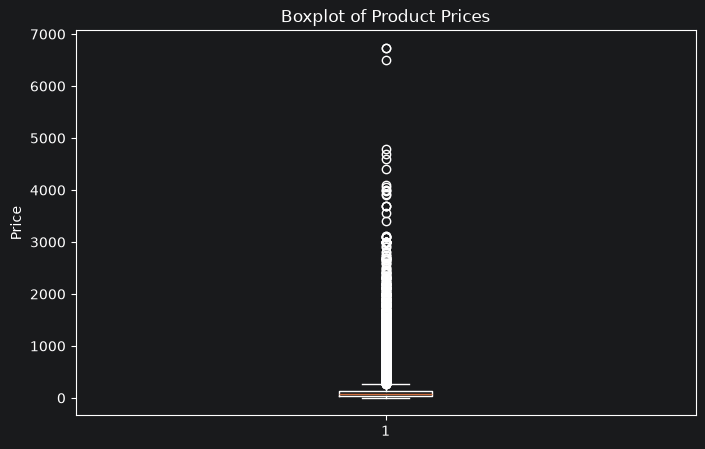

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(order_items["price"].dropna())

plt.title("Boxplot of Product Prices")

plt.ylabel("Price")

plt.show()

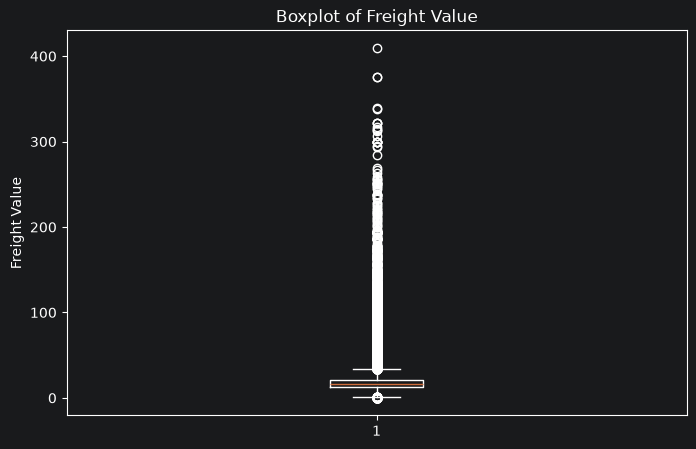

In [35]:
plt.figure(figsize=(8,5))

plt.boxplot(order_items["freight_value"].dropna())

plt.title("Boxplot of Freight Value")

plt.ylabel("Freight Value")

plt.show()

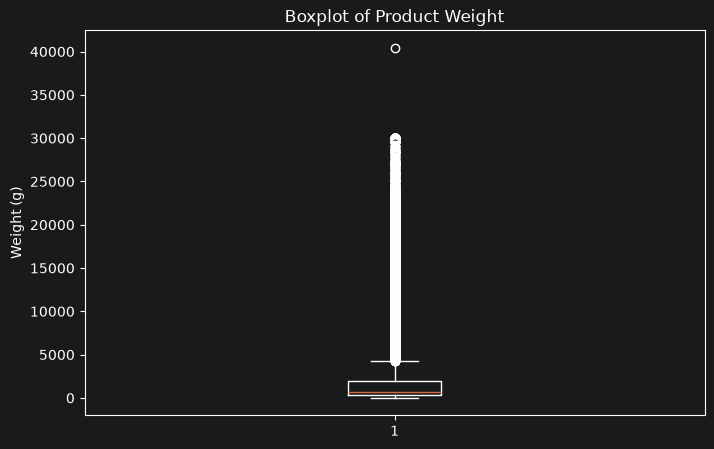

In [36]:
plt.figure(figsize=(8,5))

plt.boxplot(products["product_weight_g"].dropna())

plt.title("Boxplot of Product Weight")

plt.ylabel("Weight (g)")

plt.show()

### Observations

Several numerical variables contain extreme values, particularly product prices, freight values, and product weights.

These observations are expected in an e-commerce environment, where products vary considerably in size, weight, and price.

Since these values may represent legitimate business transactions, no outliers are removed during the initial cleaning stage.

## 9. Data Cleaning Summary

The following table summarizes the preprocessing steps completed throughout this notebook.

In [37]:
cleaning_summary = pd.DataFrame({
    "Cleaning Step": [
        "Duplicate Record Analysis",
        "Duplicate Removal",
        "Missing Value Analysis",
        "Data Type Conversion",
        "Date Validation",
        "Outlier Inspection"
    ],
    "Status": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

cleaning_summary

,Cleaning Step,Status
0,Duplicate Record Analysis,Completed
1,Duplicate Removal,Completed
2,Missing Value Analysis,Completed
3,Data Type Conversion,Completed
4,Date Validation,Completed
5,Outlier Inspection,Completed


## Final Cleaning Validation

Before exporting the processed datasets, a final validation is performed to confirm that duplicate removal and datatype transformations were applied successfully.

In [38]:
datasets = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Orders": orders,
    "Products": products,
    "Sellers": sellers,
    "Category Translation": category_translation
}

final_validation = []

for name, df in datasets.items():
    final_validation.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isna().sum().sum(),
        "Duplicate Records": df.duplicated().sum()
    })

final_validation_df = pd.DataFrame(final_validation)

final_validation_df

,Dataset,Rows,Columns,Missing Values,Duplicate Records
0,Customers,99441,5,0,0
1,Geolocation,738332,5,0,0
2,Order Items,112650,7,0,0
3,Order Payments,103886,5,0,0
4,Order Reviews,99224,7,145903,0
5,Orders,99441,8,4908,0
6,Products,32951,9,2448,0
7,Sellers,3095,4,0,0
8,Category Translation,71,2,0,0


## 10. Saving Cleaned Datasets

After completing the preprocessing steps, the cleaned datasets are saved for use in subsequent exploratory data analysis, feature engineering, and machine learning notebooks.

Saving the processed datasets ensures a consistent workflow and avoids repeating preprocessing operations.

In [39]:


PROCESSED_DATA_PATH = "../data/processed"

os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

In [40]:
datasets = {
    "customers_clean.csv": customers,
    "geolocation_clean.csv": geolocation,
    "order_items_clean.csv": order_items,
    "order_payments_clean.csv": order_payments,
    "order_reviews_clean.csv": order_reviews,
    "orders_clean.csv": orders,
    "products_clean.csv": products,
    "sellers_clean.csv": sellers,
    "category_translation_clean.csv": category_translation
}

for filename, df in datasets.items():
    df.to_csv(
        os.path.join(PROCESSED_DATA_PATH, filename),
        index=False
    )

print("All cleaned datasets have been successfully saved.")

All cleaned datasets have been successfully saved.


## 11. Conclusion

This notebook completed the initial cleaning and preprocessing stage of the Olist Brazilian E-Commerce dataset.

The workflow included duplicate analysis and removal, business-aware missing value assessment, datetime conversion, temporal validation, and outlier inspection.

Rather than applying aggressive global cleaning rules, potentially informative missing values and legitimate extreme observations were preserved for later feature-specific treatment.

The resulting processed datasets provide a consistent and reproducible foundation for exploratory data analysis, feature engineering, and machine learning development.